In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
import gc
from scipy.stats import zscore
from scipy.ndimage import gaussian_filter1d
import mne
import mne_connectivity
print(mne.__version__)
print(mne_connectivity.__version__)
from mne_connectivity import spectral_connectivity_epochs
#truncate mne print
mne.set_log_level('WARNING')
import scienceplots
plt.style.use(['science', 'no-latex'])


1.9.0
0.7.0


In [4]:
def smooth_with_gaussian(data, sigma=3):
    return gaussian_filter1d(data, sigma=sigma, axis=1) 

def preprocess(data):
    stds = np.std(data[:, :], axis=0)
    non_constant_cols = stds.astype(float) > 1e-6    #finds the time points where std is not 0
    const_cols = stds.astype(float) <= 1e-6    #finds the time points where std is 0

    z = np.zeros_like(data[:, :])   #creates an array of zeros with the same shape as the data
    z[:, non_constant_cols] = zscore(data[:, non_constant_cols], axis=0)  #in the columns where std is not 0, zscores the data
    z[:, const_cols] = np.mean(data[:, const_cols], axis=0)

 
    if np.isnan(z).any():
        raise ValueError("Data contains NaN values after normalization.")

    return z


file_numbers = [1, 2, 3, 4, 8, 14, 15, 20, 23]
def load_data():
    l_al = []
    r_al = []
    l_ar = []
    r_ar = []
    a_al =[]
    a_ar = []
    for file_number in  file_numbers:
        file_total = time.time()
        file_path = f'C:/Users/joshu/PartIIIProject/RSNNdale_attention_{file_number}_attention_test'
        load_data_start_time = time.time()
        data = pickle.load(open(file_path, 'rb'))
        elapsed_time = time.time() - load_data_start_time
        print(f"Dataset {file_number} loaded in {elapsed_time:.2f} seconds")

        attention_labels = data['label_attend'][0]
        label_left = data['label_left'][0]
        label_right = data['label_right'][0]
        attend_01 = data['attend'][0]
        trial_correct = data['trial_correct'][0]
        omitted = data['omit'][0]
        relevant = np.where((omitted == 0) & (trial_correct == 1))[0]

        left = data['SP'][0][0][relevant, 100:350, :]
        right = data['SP'][0][1][relevant, 100:350, :]
        att = data['SP'][0][2][relevant, 100:350, :]

        num_trials, num_samples, num_neurons = left.shape
        num_neurons_attention = 80

        for j in range(0, num_trials):
            for i in range(0, num_neurons):
                count_left = np.count_nonzero(left[j, :, i] == 1)
                if count_left > 0:
                    left[j, :, i] /= count_left
                count_right = np.count_nonzero(right[j, :, i] == 1)
                if count_right > 0:
                    right[j, :, i] /= count_right

            for i in range(0, num_neurons_attention):
                count_attention = np.count_nonzero(att[j, :, i] == 1)
                if count_attention > 0:
                    att[j, :, i] /= count_attention

        left = np.sum(left, axis=2)  # Return a single time series for the output
        right = np.sum(right, axis=2)  # Return a single time series for the output
        att = np.sum(att, axis=2)  # Return a single time series for the output

        left = preprocess(left)
        right = preprocess(right)
        att = preprocess(att) 
    
        # Can now split into left and right attentional modality
        left_indices_agg = np.where((omitted == 0) & (attend_01 == 0) & (label_left != label_right))[0]  # Indices of agg where left
        _, left_indices, _ = np.intersect1d(relevant, left_indices_agg, return_indices = True)   # Indices for relevant processed data where attention left
        right_indices_agg = np.where((omitted == 0) & (attend_01 == 1) & (label_left != label_right))[0]
        _, right_indices, _ = np.intersect1d(relevant, right_indices_agg, return_indices = True)


        # Splitting left and right
        l_al.append(smooth_with_gaussian(left[left_indices], sigma = 2))  # Axis 1 will smooth all of these across time
        r_al.append(smooth_with_gaussian(right[left_indices], sigma = 2))
        a_al.append(smooth_with_gaussian(att[left_indices], sigma = 2))

        l_ar.append(smooth_with_gaussian(left[right_indices], sigma = 2))
        r_ar.append(smooth_with_gaussian(right[right_indices], sigma = 2))
        a_ar.append(smooth_with_gaussian(att[right_indices], sigma = 2))
        

        del left, right, att, data
        gc.collect()
        file_time = time.time() - load_data_start_time
        print(f'Dataset {file_number} complete in {file_time:.2f} seconds')

    return l_al, r_al, l_ar, r_ar, a_al, a_ar



In [5]:
l_al, r_al, l_ar, r_ar, a_al, a_ar = load_data()

Dataset 1 loaded in 16.15 seconds
Dataset 1 complete in 18.90 seconds
Dataset 2 loaded in 5.74 seconds
Dataset 2 complete in 8.28 seconds
Dataset 3 loaded in 5.59 seconds
Dataset 3 complete in 7.50 seconds
Dataset 4 loaded in 5.39 seconds
Dataset 4 complete in 6.98 seconds
Dataset 8 loaded in 6.68 seconds
Dataset 8 complete in 8.84 seconds
Dataset 14 loaded in 5.18 seconds
Dataset 14 complete in 8.17 seconds
Dataset 15 loaded in 6.21 seconds
Dataset 15 complete in 8.43 seconds
Dataset 20 loaded in 6.04 seconds
Dataset 20 complete in 9.17 seconds
Dataset 23 loaded in 7.18 seconds
Dataset 23 complete in 9.83 seconds


In [10]:
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
sfreq = 500.0
ch_names = ['left_input', 'right_input', 'attention_layer']
ch_types = ['eeg', 'eeg', 'eeg']

freq_ranges = [(0, 4), (4, 8), (8, 13), (13, 30), (30, 80)]

# Initialize granger_results as a nested dictionary for each file, condition, and band


def granger_calc(left, right, attention):
    results = []
    freqs = []
    results_back = []
    results_tr = []
    for idx, fn in enumerate(file_numbers):
        info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)

        data= np.stack([
            left[idx], 
            right[idx], 
            attention[idx]
        ], axis=1) 
        print(data.shape)

        epochs = mne.EpochsArray(
            data,
            info, 
            tmin=0, 
            baseline=None
        )

            # Define channel indices for Granger causality
        seeds = np.array([[0], [1]])
        targets = np.array([[2], [2]])
        indices = (seeds, targets)

        # Compute Granger causality
        gc = spectral_connectivity_epochs(
            epochs, method='gc', indices=indices, sfreq=sfreq,
            fmin=4, fmax=80.0, tmin=0.0, tmax=(250 - 1) / sfreq, gc_n_lags = 60)
        
        gc_tr = spectral_connectivity_epochs(
        epochs, method='gc_tr', indices=indices, sfreq=sfreq,
        fmin=10, fmax=80.0, tmin=0.0, tmax=(250 - 1) / sfreq, gc_n_lags= 40)
      
        # Extract Granger causality data
        gc_data = gc.get_data()
        gc_data_tr = gc_tr.get_data()
        freqs = gc.freqs

        results.append(gc_data)
        print(gc_data.shape)

        results_tr.append(gc_data_tr)
        print(gc_data_tr.shape)
        #---------------------------

        seed_back = np.array([[2], [2]])
        target_back = np.array([[0], [1]])
        indices_back = (seed_back, target_back)

        gc_back = spectral_connectivity_epochs(
            epochs, method='gc', indices=indices_back, sfreq=sfreq,
            fmin=10, fmax=80.0, tmin=0.0, tmax=(250 - 1) / sfreq, gc_n_lags = 40)

        gc_back_data = gc_back.get_data()
        results_back.append(gc_back_data)
        #---------------------------
    return results, results_back, results_tr, freqs


In [11]:
left_results, left_results_back, left_results_tr, freqs = granger_calc(l_al, r_al, a_al)
right_results, right_results_back, right_results_tr, freqs = granger_calc(l_ar, r_ar, a_ar)

(328, 3, 250)


C:\Users\joshu\AppData\Local\Temp\ipykernel_800\2271677683.py:39: RuntimeWarning: There were no Annotations stored in <EpochsArray | 328 events (all good), 0 – 0.498 s (baseline off), ~1.9 MiB, data loaded,
 '1': 328>, so metadata was not modified.
  gc = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_800\2271677683.py:39: RuntimeWarning: fmin=4.000 Hz corresponds to 2.000 < 5 cycles based on the epoch length 0.500 sec, need at least 1.250 sec epochs or fmin=10.000. Spectrum estimate will be unreliable.
  gc = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_800\2271677683.py:43: RuntimeWarning: There were no Annotations stored in <EpochsArray | 328 events (all good), 0 – 0.498 s (baseline off), ~1.9 MiB, data loaded,
 '1': 328>, so metadata was not modified.
  gc_tr = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_800\2271677683.py:63: RuntimeWarning: There were no Annotations stored in <EpochsArray | 328 e

(2, 39)
(2, 36)
(333, 3, 250)


C:\Users\joshu\AppData\Local\Temp\ipykernel_800\2271677683.py:39: RuntimeWarning: There were no Annotations stored in <EpochsArray | 333 events (all good), 0 – 0.498 s (baseline off), ~1.9 MiB, data loaded,
 '1': 333>, so metadata was not modified.
  gc = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_800\2271677683.py:39: RuntimeWarning: fmin=4.000 Hz corresponds to 2.000 < 5 cycles based on the epoch length 0.500 sec, need at least 1.250 sec epochs or fmin=10.000. Spectrum estimate will be unreliable.
  gc = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_800\2271677683.py:43: RuntimeWarning: There were no Annotations stored in <EpochsArray | 333 events (all good), 0 – 0.498 s (baseline off), ~1.9 MiB, data loaded,
 '1': 333>, so metadata was not modified.
  gc_tr = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_800\2271677683.py:63: RuntimeWarning: There were no Annotations stored in <EpochsArray | 333 e

(2, 39)
(2, 36)
(329, 3, 250)


...

(2, 39)
(2, 36)
(350, 3, 250)


C:\Users\joshu\AppData\Local\Temp\ipykernel_800\2271677683.py:63: RuntimeWarning: There were no Annotations stored in <EpochsArray | 366 events (all good), 0 – 0.498 s (baseline off), ~2.1 MiB, data loaded,
 '1': 366>, so metadata was not modified.
  gc_back = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_800\2271677683.py:39: RuntimeWarning: There were no Annotations stored in <EpochsArray | 350 events (all good), 0 – 0.498 s (baseline off), ~2.0 MiB, data loaded,
 '1': 350>, so metadata was not modified.
  gc = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_800\2271677683.py:39: RuntimeWarning: fmin=4.000 Hz corresponds to 2.000 < 5 cycles based on the epoch length 0.500 sec, need at least 1.250 sec epochs or fmin=10.000. Spectrum estimate will be unreliable.
  gc = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_800\2271677683.py:43: RuntimeWarning: There were no Annotations stored in <EpochsArray | 350

(2, 39)
(2, 36)
(339, 3, 250)


C:\Users\joshu\AppData\Local\Temp\ipykernel_800\2271677683.py:39: RuntimeWarning: There were no Annotations stored in <EpochsArray | 339 events (all good), 0 – 0.498 s (baseline off), ~1.9 MiB, data loaded,
 '1': 339>, so metadata was not modified.
  gc = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_800\2271677683.py:39: RuntimeWarning: fmin=4.000 Hz corresponds to 2.000 < 5 cycles based on the epoch length 0.500 sec, need at least 1.250 sec epochs or fmin=10.000. Spectrum estimate will be unreliable.
  gc = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_800\2271677683.py:43: RuntimeWarning: There were no Annotations stored in <EpochsArray | 339 events (all good), 0 – 0.498 s (baseline off), ~1.9 MiB, data loaded,
 '1': 339>, so metadata was not modified.
  gc_tr = spectral_connectivity_epochs(
C:\Users\joshu\AppData\Local\Temp\ipykernel_800\2271677683.py:63: RuntimeWarning: There were no Annotations stored in <EpochsArray | 339 e

(2, 39)
(2, 36)


In [ ]:
# left_results: shape (datasets, 2, 40) -- [0]=in, [1]=out
# right_results: shape (datasets, 2, 40) -- [0]=out, [1]=in

print(freqs)

# Stack the "in" condition: left_results[:,0,:] and right_results[:,1,:]
gc_in = np.concatenate([
    np.stack(left_results, axis=0)[:, 0, :],
    np.stack(right_results, axis=0)[:, 1, :]
], axis=0)  # shape (datasets*2, n_freqs)

# Stack the "out" condition: left_results[:,1,:] and right_results[:,0,:]
gc_out = np.concatenate([
    np.stack(left_results, axis=0)[:, 1, :],
    np.stack(right_results, axis=0)[:, 0, :]
], axis=0)  # shape (datasets*2, n_freqs)

# Calculate mean and SEM across all datasets (axis=0)
gc_in_mean = np.mean(gc_in, axis=0)
gc_in_sem = np.std(gc_in, axis=0, ddof=1) / np.sqrt(gc_in.shape[0])

gc_out_mean = np.mean(gc_out, axis=0)
gc_out_sem = np.std(gc_out, axis=0, ddof=1) / np.sqrt(gc_out.shape[0])

# 1. Plot GC Spectrum: In vs Out (Mean ± SEM)
# plt.figure(figsize=(10, 6), dpi=300)
# plt.plot(freqs, gc_in_mean, label='In', color='teal', linewidth=2)
# plt.fill_between(freqs, gc_in_mean - gc_in_sem, gc_in_mean + gc_in_sem, color='teal', alpha=0.2)
# plt.plot(freqs, gc_out_mean, label='Out', color='red', linewidth=2)
# plt.fill_between(freqs, gc_out_mean - gc_out_sem, gc_out_mean + gc_out_sem, color='red', alpha=0.2)
# plt.xlabel('Frequency (Hz)', fontsize=20)
# plt.ylabel('Granger Causality', fontsize=20)
# plt.title('GC Spectrum: In vs Out (Mean ± SEM)', fontsize=22)
# plt.legend(fontsize=16)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# # 2. Plot log10(GC) Spectrum: In vs Out (Mean ± SEM)
# eps = 1e-10
# plt.figure(figsize=(10, 6), dpi=300)
# plt.plot(freqs, np.log10(gc_in_mean + eps), label='In', color='teal', linewidth=2)
# plt.fill_between(freqs, np.log10(gc_in_mean - gc_in_sem + eps), np.log10(gc_in_mean + gc_in_sem + eps), color='teal', alpha=0.2)
# plt.plot(freqs, np.log10(gc_out_mean + eps), label='Out', color='red', linewidth=2)
# plt.fill_between(freqs, np.log10(gc_out_mean - gc_out_sem + eps), np.log10(gc_out_mean + gc_out_sem + eps), color='red', alpha=0.2)
# plt.xlabel('Frequency (Hz)', fontsize=20)
# plt.ylabel('log10(Granger Causality)', fontsize=20)
# plt.title('Log GC Spectrum: In vs Out (Mean ± SEM)', fontsize=22)
# plt.legend(fontsize=16)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# 3. Plot _tr data (transfer entropy direction)
# left_results_tr: shape (datasets, 2, n_freqs)
# right_results_tr: shape (datasets, 2, n_freqs)

gc_tr_in = np.concatenate([
    np.stack(left_results_tr, axis=0)[:, 0, :],
    np.stack(right_results_tr, axis=0)[:, 1, :]
], axis=0)
gc_tr_out = np.concatenate([
    np.stack(left_results_tr, axis=0)[:, 1, :],
    np.stack(right_results_tr, axis=0)[:, 0, :]
], axis=0)

gc_tr_in_mean = np.mean(gc_tr_in, axis=0)
gc_tr_in_sem = np.std(gc_tr_in, axis=0, ddof=1) / np.sqrt(gc_tr_in.shape[0])
gc_tr_out_mean = np.mean(gc_tr_out, axis=0)
gc_tr_out_sem = np.std(gc_tr_out, axis=0, ddof=1) / np.sqrt(gc_tr_out.shape[0])

# plt.figure(figsize=(10, 6), dpi=300)
# plt.plot(freqs, gc_tr_in_mean, label='In (TR)', color='teal', linewidth=2)
# plt.fill_between(freqs, gc_tr_in_mean - gc_tr_in_sem, gc_tr_in_mean + gc_tr_in_sem, color='teal', alpha=0.2)
# plt.plot(freqs, gc_tr_out_mean, label='Out (TR)', color='red', linewidth=2)
# plt.fill_between(freqs, gc_tr_out_mean - gc_tr_out_sem, gc_tr_out_mean + gc_tr_out_sem, color='red', alpha=0.2)
# plt.xlabel('Frequency (Hz)', fontsize=20)
# plt.ylabel('GC (TR direction)', fontsize=20)
# plt.title('GC (TR) Spectrum: In vs Out (Mean ± SEM)', fontsize=22)
# plt.legend(fontsize=16)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# 4. Plot difference between forward GC and TR GC (gc - gc_tr)
# (gc_in - gc_tr_in) and (gc_out - gc_tr_out)
gc_in_tr_diff = gc_in - gc_tr_in
gc_out_tr_diff = gc_out - gc_tr_out

gc_in_tr_diff_mean = np.mean(gc_in_tr_diff, axis=0)
gc_in_tr_diff_sem = np.std(gc_in_tr_diff, axis=0, ddof=1) / np.sqrt(gc_in_tr_diff.shape[0])
gc_out_tr_diff_mean = np.mean(gc_out_tr_diff, axis=0)
gc_out_tr_diff_sem = np.std(gc_out_tr_diff, axis=0, ddof=1) / np.sqrt(gc_out_tr_diff.shape[0])

# Combined plot: log10(GC - GC_tr) on top, linear (GC - GC_tr) on bottom
# fig, axs = plt.subplots(2, 1, figsize=(10, 12), dpi=300, sharex=True)

# # Top: log10(GC - GC_tr)
# eps = 1e-10  # to avoid log(0)
# axs[0].plot(freqs, np.log10(gc_in_tr_diff_mean + eps), label='In (forward - TR)', color='teal', linewidth=2)
# axs[0].fill_between(freqs, np.log10(gc_in_tr_diff_mean - gc_in_tr_diff_sem + eps), np.log10(gc_in_tr_diff_mean + gc_in_tr_diff_sem + eps), color='teal', alpha=0.2)
# axs[0].plot(freqs, np.log10(gc_out_tr_diff_mean + eps), label='Out (forward - TR)', color='red', linewidth=2)
# axs[0].fill_between(freqs, np.log10(gc_out_tr_diff_mean - gc_out_tr_diff_sem + eps), np.log10(gc_out_tr_diff_mean + gc_out_tr_diff_sem + eps), color='red', alpha=0.2)
# axs[0].set_ylabel('log10(GC (forward - TR))', fontsize=20)
# axs[0].set_title('Log GC (forward - TR): In vs Out (Mean ± SEM)', fontsize=22)
# axs[0].legend(fontsize=16)
# axs[0].grid(True, alpha=0.3)

# # Bottom: linear (GC - GC_tr)
# axs[1].plot(freqs, gc_in_tr_diff_mean, label='In (forward - TR)', color='teal', linewidth=2)
# axs[1].fill_between(freqs, gc_in_tr_diff_mean - gc_in_tr_diff_sem, gc_in_tr_diff_mean + gc_in_tr_diff_sem, color='teal', alpha=0.2)
# axs[1].plot(freqs, gc_out_tr_diff_mean, label='Out (forward - TR)', color='red', linewidth=2)
# axs[1].fill_between(freqs, gc_out_tr_diff_mean - gc_out_tr_diff_sem, gc_out_tr_diff_mean + gc_out_tr_diff_sem, color='red', alpha=0.2)
# axs[1].set_xlabel('Frequency (Hz)', fontsize=20)
# axs[1].set_ylabel('GC (forward - TR)', fontsize=20)
# axs[1].set_title('GC (forward - TR): In vs Out (Mean ± SEM)', fontsize=22)
# axs[1].legend(fontsize=16)
# axs[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# 5. Plot difference between forward and reversed GC (directionality)
# left_results_back: shape (datasets, 2, n_freqs)
# right_results_back: shape (datasets, 2, n_freqs)

gc_back_in = np.concatenate([
    np.stack(left_results_back, axis=0)[:, 0, :],
    np.stack(right_results_back, axis=0)[:, 1, :]
], axis=0)
gc_back_out = np.concatenate([
    np.stack(left_results_back, axis=0)[:, 1, :],
    np.stack(right_results_back, axis=0)[:, 0, :]
], axis=0)

# Difference: (forward - reversed)
gc_in_diff = gc_in - gc_back_in
gc_out_diff = gc_out - gc_back_out

gc_in_diff_mean = np.mean(gc_in_diff, axis=0)
gc_in_diff_sem = np.std(gc_in_diff, axis=0, ddof=1) / np.sqrt(gc_in_diff.shape[0])
gc_out_diff_mean = np.mean(gc_out_diff, axis=0)
gc_out_diff_sem = np.std(gc_out_diff, axis=0, ddof=1) / np.sqrt(gc_out_diff.shape[0])

# plt.figure(figsize=(10, 6), dpi=300)
# plt.plot(freqs, gc_in_diff_mean, label='In (forward - reversed)', color='teal', linewidth=2)
# plt.fill_between(freqs, gc_in_diff_mean - gc_in_diff_sem, gc_in_diff_mean + gc_in_diff_sem, color='teal', alpha=0.2)
# plt.plot(freqs, gc_out_diff_mean, label='Out (forward - reversed)', color='red', linewidth=2)
# plt.fill_between(freqs, gc_out_diff_mean - gc_out_diff_sem, gc_out_diff_mean + gc_out_diff_sem, color='red', alpha=0.2)
# plt.xlabel('Frequency (Hz)', fontsize=20)
# plt.ylabel('GC Directionality (forward - reversed)', fontsize=20)
# plt.title('GC Directionality: In vs Out (Mean ± SEM)', fontsize=22)
# plt.legend(fontsize=16)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

from mpl_toolkits.axes_grid1.inset_locator import inset_axes



[10.0, 12.0, 14.0, 16.0, 18.0, 20.0, 22.0, 24.0, 26.0, 28.0, 30.0, 32.0, 34.0, 36.0, 38.0, 40.0, 42.0, 44.0, 46.0, 48.0, 50.0, 52.0, 54.0, 56.0, 58.0, 60.0, 62.0, 64.0, 66.0, 68.0, 70.0, 72.0, 74.0, 76.0, 78.0, 80.0]


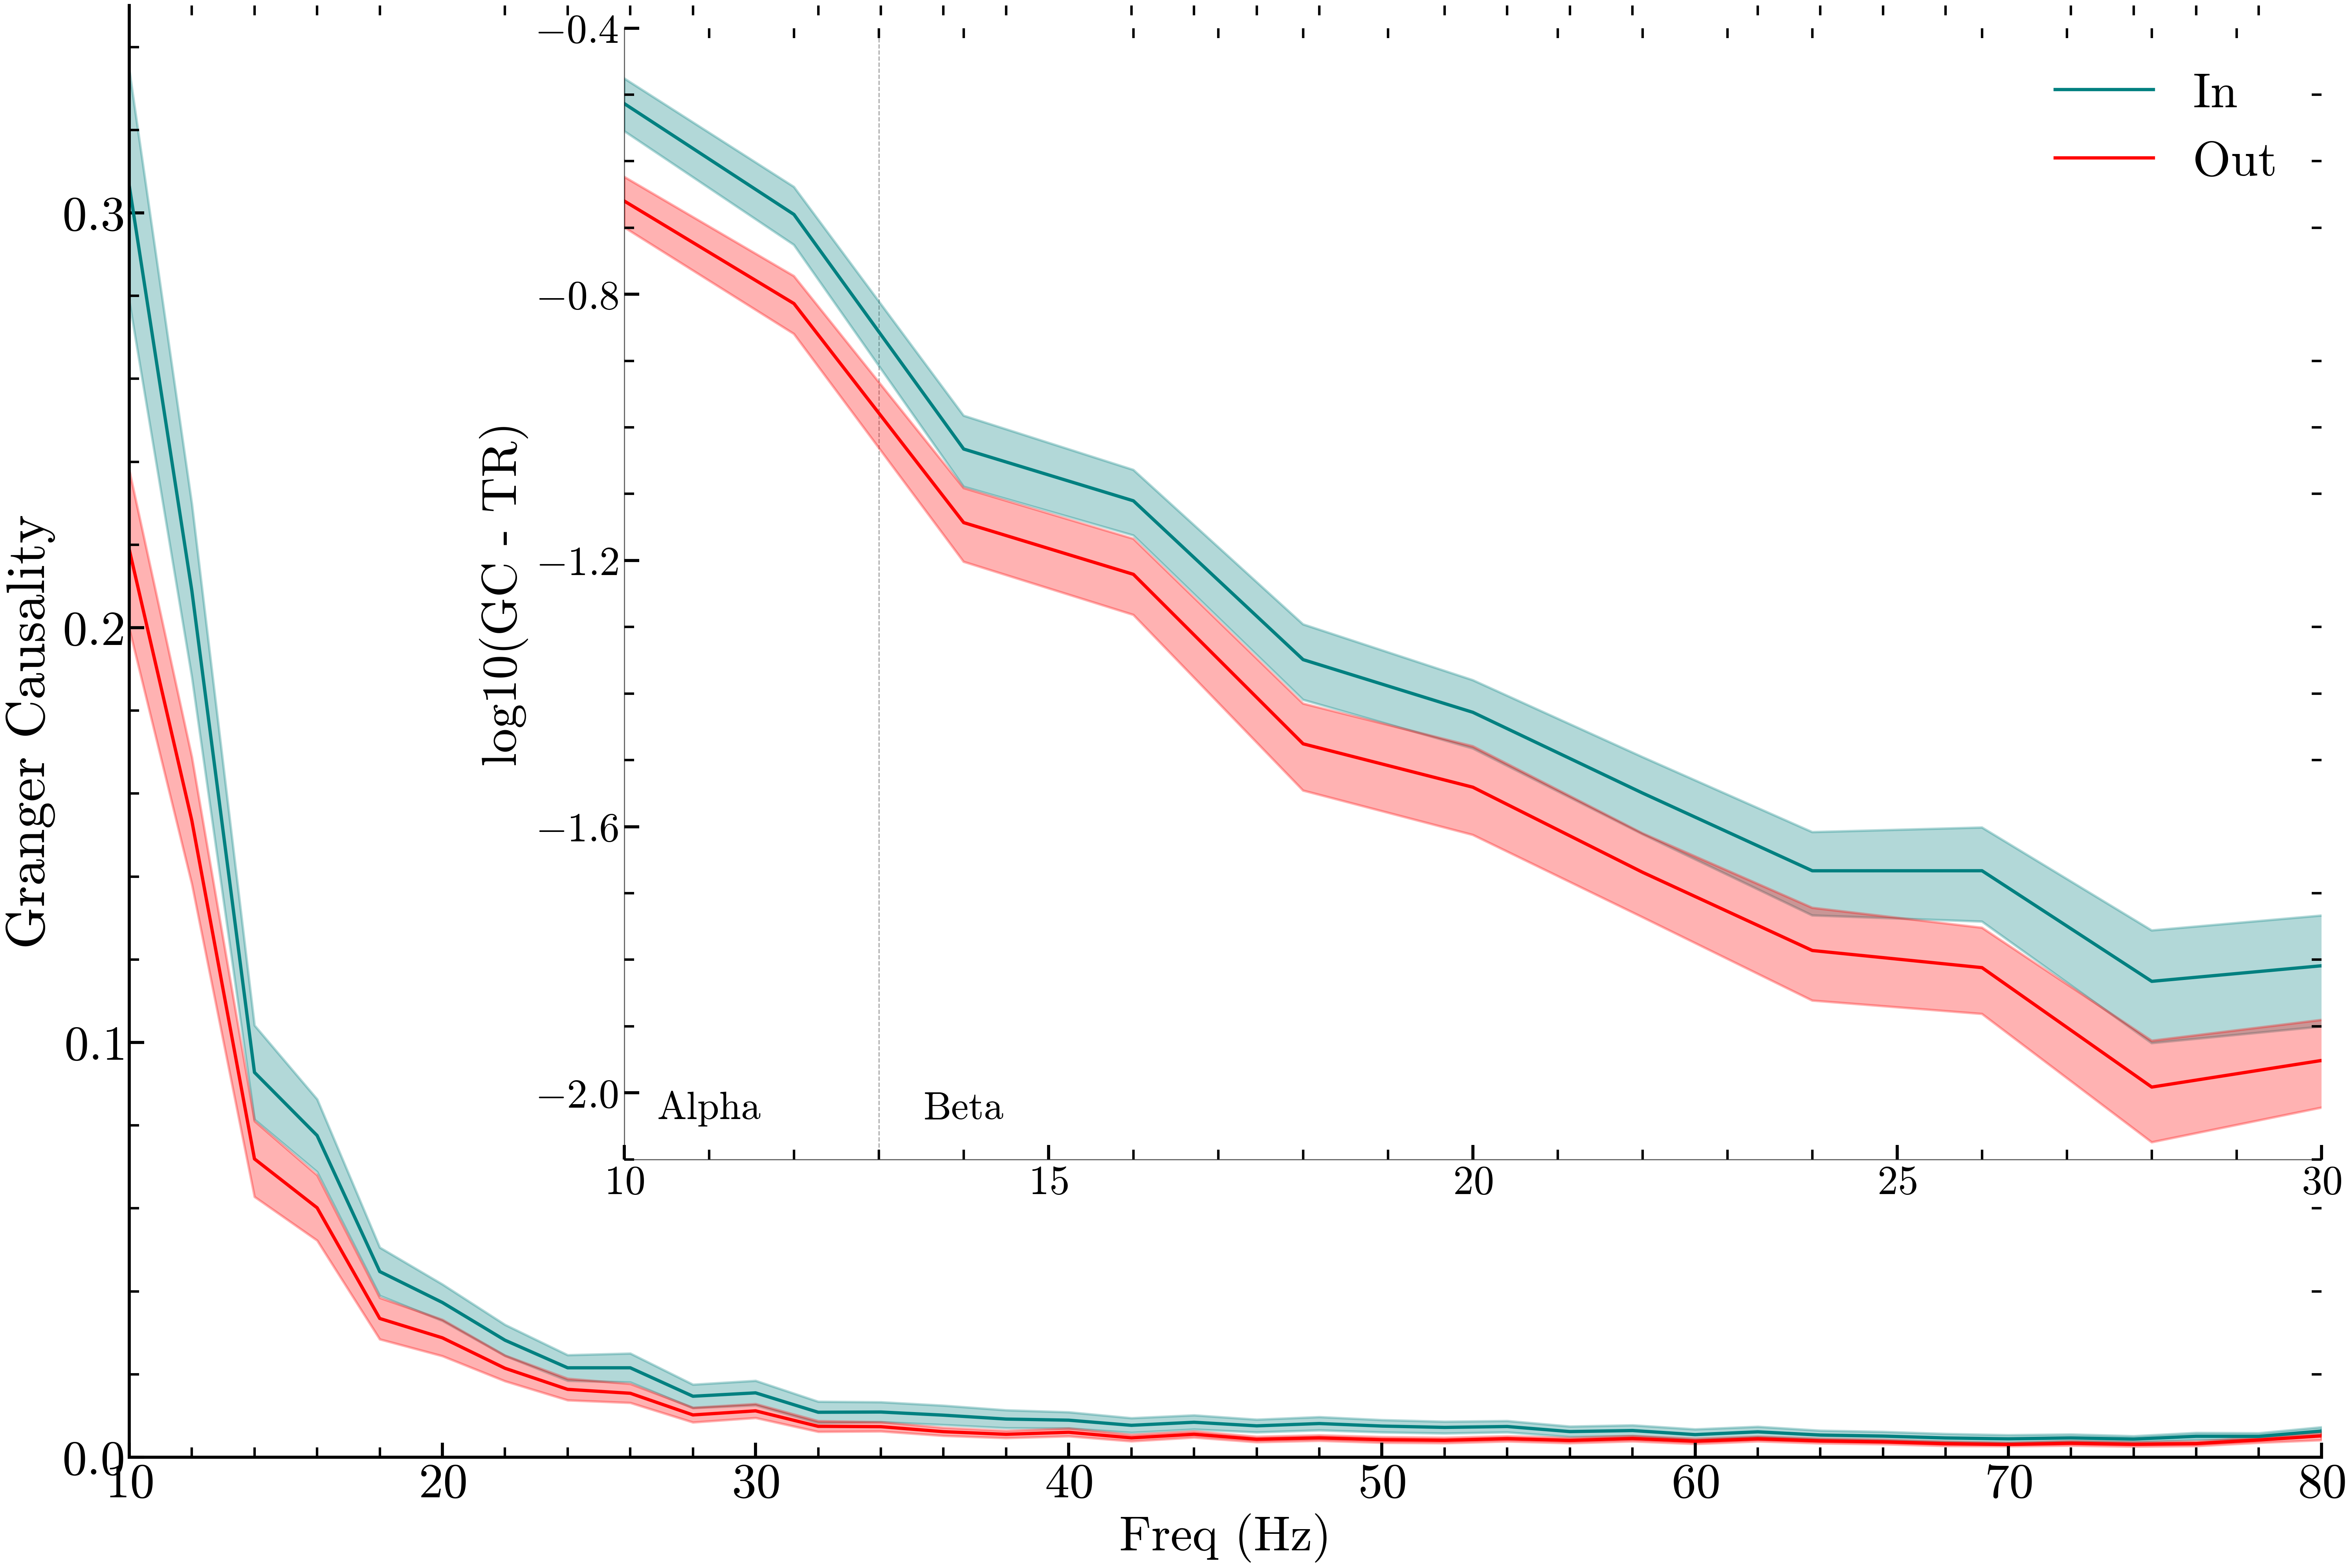

In [ ]:
# Add inset plot to the first (broadband) plot
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
fig, ax = plt.subplots(figsize=(24, 16), dpi=300)

ax.plot(freqs, gc_in_tr_diff_mean, label='In (forward - TR)', color='teal', linewidth=2)
ax.fill_between(freqs, gc_in_tr_diff_mean - gc_in_tr_diff_sem, gc_in_tr_diff_mean + gc_in_tr_diff_sem, color='teal', alpha=0.3)
ax.plot(freqs, gc_out_tr_diff_mean, label='Out (forward - TR)', color='red', linewidth=2)
ax.fill_between(freqs, gc_out_tr_diff_mean - gc_out_tr_diff_sem, gc_out_tr_diff_mean + gc_out_tr_diff_sem, color='red', alpha=0.3)


ax.set_xlim(10, 80)
ax.set_ylabel('log10(GC (forward - TR))', fontsize=25)
ax.set_ylim(0, 0.35)
ax.set_yticks([0, 0.1, 0.2, 0.3])
ax.set_ylabel('Granger Causality', fontsize=33)
ax.tick_params(axis='both', labelsize=30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
ax.set_xlabel('Freq (Hz)', fontsize=30)


# Add inset plot using fig.add_axes
inset_width = 0.6
inset_height = 0.6
left = 0.1 + inset_width / 3
bottom = 0.068 + inset_height / 3


eps = 1e-10  # to avoid log(0)
axins = fig.add_axes([left, bottom, inset_width, inset_height])
axins.plot(freqs, np.log10(gc_in_tr_diff_mean + eps), label='In', color='teal', linewidth=2)
axins.fill_between(freqs, np.log10(gc_in_tr_diff_mean - gc_in_tr_diff_sem + eps), np.log10(gc_in_tr_diff_mean + gc_in_tr_diff_sem + eps), color='teal', alpha=0.3)
axins.plot(freqs, np.log10(gc_out_tr_diff_mean + eps), label='Out', color='red', linewidth=2)
axins.fill_between(freqs, np.log10(gc_out_tr_diff_mean - gc_out_tr_diff_sem + eps), np.log10(gc_out_tr_diff_mean + gc_out_tr_diff_sem + eps), color='red', alpha=0.3)
axins.set_xlim(10, 30)
axins.set_xticks([10, 15, 20, 25, 30])
axins.set_ylim(-2.1,-0.45)
axins.set_yticks([-2, -1.6, -1.2, -0.8, -0.4])
axins.set_ylabel('log10(GC - TR)', fontsize=30)
axins.tick_params(axis='both', labelsize=25)
axins.spines['top'].set_visible(False)
axins.spines['right'].set_visible(False)
axins.tick_params(top=False, right=False)
# Add custom x-axis label for bands with vertical lines and band names, centered
band_centers = [11, 14]  
for x, label in zip(band_centers, ['Alpha', 'Beta']):
    axins.text(x, -2.05, f'{label}', ha='center', va='bottom', fontsize=24, rotation=0)

axins.axvline(13, color='gray', linestyle='--', linewidth=0.7, alpha=0.7, zorder=0)
for spine in axins.spines.values():
    spine.set_linewidth(0.7)
    spine.set_alpha(0.6)

axins.legend(fontsize=30, loc='upper right', frameon=False)

plt.show()

In [ ]:
import numpy as np
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

# === Assumes you already have these arrays ===
# gc_in_tr_diff: shape (n_subjects, n_freqs)
# gc_out_tr_diff: shape (n_subjects, n_freqs)
# freqs: shape (n_freqs,)
freqs = np.array(freqs)  # Ensure it's a NumPy array


# === 1. Paired t-tests per frequency ===
t_stats = []
p_values = []

for i in range(gc_in_tr_diff.shape[1]):
    t, p = ttest_rel(gc_in_tr_diff[:, i], gc_out_tr_diff[:, i])
    t_stats.append(t)
    p_values.append(p)

t_stats = np.array(t_stats)
p_values = np.array(p_values)

# === 2. FDR correction ===
rej, pvals_corrected, _, _ = multipletests(p_values, method='fdr_bh')


# === 3. Extract significant results ===
significant_freqs = freqs[rej]
significant_tvals = t_stats[rej]
significant_pvals = pvals_corrected[rej]

# === 4. Report formatted stats ===
print("=== Granger Causality Statistical Results (FDR-corrected) ===")
if len(significant_freqs) > 0:
    for f, t, p in zip(significant_freqs, significant_tvals, significant_pvals):
        print(f"Frequency: {f:.1f} Hz | t = {t:.3f} | corrected p = {p:.4f}")
    print(f"\nTotal significant frequencies: {len(significant_freqs)} out of {len(freqs)}")
else:
    print("No frequencies reached significance after FDR correction.")


# === 5. Band-averaged Granger causality tests ===

# Define standard frequency bands
bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (10, 13),
    "beta": (14, 30),
    "gamma": (31, 80)
}

print("\n=== Band-Averaged Granger Causality (In vs Out, Paired t-tests, FDR-corrected) ===")

# Ensure freqs is a NumPy array
freqs = np.array(freqs)

band_names = []
t_stats_band = []
p_values_band = []

for band_name, (fmin, fmax) in bands.items():
    # Get frequency indices within this band
    band_mask = (freqs >= fmin) & (freqs <= fmax)

    # Mean per subject within the band
    in_band = gc_in_tr_diff[:, band_mask].mean(axis=1)
    out_band = gc_out_tr_diff[:, band_mask].mean(axis=1)

    # Paired t-test
    t_stat, p_value = ttest_rel(in_band, out_band)
    band_names.append(band_name)
    t_stats_band.append(t_stat)
    p_values_band.append(p_value)

# FDR correction across bands
from statsmodels.stats.multitest import multipletests
rej_band, pvals_corrected_band, _, _ = multipletests(p_values_band, method='fdr_bh')

for i, band_name in enumerate(band_names):
    print(f"{band_name.capitalize()} band: t = {t_stats_band[i]:.3f}, p = {p_values_band[i]:.4f}, "
          f"FDR-corrected p = {pvals_corrected_band[i]:.4f}, Significant: {rej_band[i]}")

=== Granger Causality Statistical Results (FDR-corrected) ===
No frequencies reached significance after FDR correction.

=== Band-Averaged Granger Causality (In vs Out, Paired t-tests, FDR-corrected) ===
Delta band: t = nan, p = nan, FDR-corrected p = nan, Significant: False
Theta band: t = nan, p = nan, FDR-corrected p = nan, Significant: False
Alpha band: t = 2.342, p = 0.0316, FDR-corrected p = nan, Significant: False
Beta band: t = 2.108, p = 0.0501, FDR-corrected p = nan, Significant: False
Gamma band: t = 2.034, p = 0.0579, FDR-corrected p = nan, Significant: False


C:\Users\joshu\AppData\Local\Temp\ipykernel_20920\2480959097.py:68: RuntimeWarning: Mean of empty slice.
  in_band = gc_in_tr_diff[:, band_mask].mean(axis=1)
c:\Users\joshu\nice\AllCode\PythonScripts\testcodegranger\granger_venv\Lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\joshu\AppData\Local\Temp\ipykernel_20920\2480959097.py:69: RuntimeWarning: Mean of empty slice.
  out_band = gc_out_tr_diff[:, band_mask].mean(axis=1)


In [ ]:
import numpy as np
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

# === Assumes you already have these arrays ===
# gc_in_tr_diff: shape (n_subjects, n_freqs)
# gc_out_tr_diff: shape (n_subjects, n_freqs)
# freqs: shape (n_freqs,)
freqs = np.array(freqs)  # Ensure it's a NumPy array


# === 1. Paired t-tests per frequency ===
t_stats = []
p_values = []

for i in range(gc_in.shape[1]):
    t, p = ttest_rel(gc_in[:, i], gc_out[:, i])
    t_stats.append(t)
    p_values.append(p)

t_stats = np.array(t_stats)
p_values = np.array(p_values)

# === 2. FDR correction ===
rej, pvals_corrected, _, _ = multipletests(p_values, method='fdr_bh')


# === 3. Extract significant results ===
significant_freqs = freqs[rej]
significant_tvals = t_stats[rej]
significant_pvals = pvals_corrected[rej]

# === 4. Report formatted stats ===
print("=== Granger Causality Statistical Results (FDR-corrected) ===")
if len(significant_freqs) > 0:
    for f, t, p in zip(significant_freqs, significant_tvals, significant_pvals):
        print(f"Frequency: {f:.1f} Hz | t = {t:.3f} | corrected p = {p:.4f}")
    print(f"\nTotal significant frequencies: {len(significant_freqs)} out of {len(freqs)}")
else:
    print("No frequencies reached significance after FDR correction.")


# === 5. Band-averaged Granger causality tests ===

# Define standard frequency bands
bands = {
    "alpha": (10, 13),
    "beta": (14, 30),
    "gamma": (31, 80)
}

print("\n=== Band-Averaged Granger Causality (In vs Out, Paired t-tests, FDR-corrected) ===")

# Ensure freqs is a NumPy array
freqs = np.array(freqs)

band_names = []
t_stats_band = []
p_values_band = []

for band_name, (fmin, fmax) in bands.items():
    # Get frequency indices within this band
    band_mask = (freqs >= fmin) & (freqs <= fmax)

    # Mean per subject within the band
    in_band = gc_in_tr_diff[:, band_mask].mean(axis=1)
    out_band = gc_out_tr_diff[:, band_mask].mean(axis=1)

    # Paired t-test
    t_stat, p_value = ttest_rel(in_band, out_band)
    band_names.append(band_name)
    t_stats_band.append(t_stat)
    p_values_band.append(p_value)

print(f"t_stats_band: {t_stats_band}")
print(f"p_values_band: {p_values_band}")

# FDR correction across bands
from statsmodels.stats.multitest import multipletests
rej_band, pvals_corrected_band, _, _ = multipletests(p_values_band, method='fdr_bh')

for i, band_name in enumerate(band_names):
    print(f"{band_name.capitalize()} band: t = {t_stats_band[i]:.3f}, p = {p_values_band[i]:.4f}, "
          f"FDR-corrected p = {pvals_corrected_band[i]:.4f}, Significant: {rej_band[i]}")

=== Granger Causality Statistical Results (FDR-corrected) ===
No frequencies reached significance after FDR correction.

=== Band-Averaged Granger Causality (In vs Out, Paired t-tests, FDR-corrected) ===
t_stats_band: [np.float64(2.3417294718972546), np.float64(2.10847941566641), np.float64(2.034067900346338)]
p_values_band: [np.float64(0.031631052569971764), np.float64(0.05012968319183112), np.float64(0.057854373771442806)]
Alpha band: t = 2.342, p = 0.0316, FDR-corrected p = 0.0579, Significant: False
Beta band: t = 2.108, p = 0.0501, FDR-corrected p = 0.0579, Significant: False
Gamma band: t = 2.034, p = 0.0579, FDR-corrected p = 0.0579, Significant: False


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1) Activate science style with more modest font size
plt.style.use(['science', 'notebook', 'no-latex'])
sns.set_context("talk", font_scale=1.0)

# 2) Build DataFrame
data = []
for i, band in enumerate(bands):
    for subj in range(g_in.shape[0]):
        data.append({"Band": band, "Value": g_in[subj, i], "Condition": "In"})
        data.append({"Band": band, "Value": g_out[subj, i], "Condition": "Out"})
df = pd.DataFrame(data)

# 3) Single plot for all bands, keep boxplot formatting
fig, ax = plt.subplots(figsize=(13, 7), dpi=300)

sns.boxplot(
    data=df, x="Band", y="Value", hue="Condition",
    boxprops=dict(alpha=0.6, linewidth=1, edgecolor="k"),
    whiskerprops={'color':'k', 'linewidth':1.0},
    capprops={'color':'k', 'linewidth':1.0},  # Make caps (top and bottom lines) normal
    medianprops={'color':'k', 'linewidth':1},
    width=0.5,
    palette={"In": "teal", "Out": "red"},
    showcaps=True,  # Show caps
    showfliers=True,  # Show outliers
    ax=ax
)

# Remove seaborn's default legend so only the custom legend is shown
if ax.get_legend() is not None:
    ax.get_legend().remove()

# Set y-limits and y-ticks
all_vals = df['Value'].values
ax.set_ylim(0, 0.01)
ax.set_yticks([0, 0.01])
ax.set_yticklabels([f"{0}", f"{0.01:.2f}"])

ax.set_ylabel("Granger Causality", fontsize=35)
ax.yaxis.set_ticks_position('left')
ax.tick_params(axis='y', labelsize=30, right=False, top=False)  # Remove top ticks

# x-axis: add asterisks to delta, theta, alpha, keep lowercase
bands_with_asterisk = [band + '*' if band in ['delta', 'theta', 'alpha'] else band for band in bands]
ax.set_xlabel("")
ax.set_xticks(np.arange(len(bands)))
ax.set_xticklabels(bands_with_asterisk, fontsize=30)
# Draw a solid black line at y=0 across the width of the plot
ax.axhline(0, color='k', linewidth=2.5, zorder=0)
sns.despine(ax=ax, top=True, right=True, left=False, bottom=True, trim=True)

# Make axis lines less thick
for spine in ax.spines.values():
    spine.set_linewidth(1)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='teal', edgecolor='k', label='In', alpha=0.6),
    Patch(facecolor='#d62728', edgecolor='k', label='Out', alpha=0.6)
]
fig.legend(handles=legend_elements, loc='lower right', fontsize=27, frameon=False, bbox_to_anchor=(0.98, 0.7))

plt.tight_layout()
plt.show()

NameError: name 'g_in' is not defined

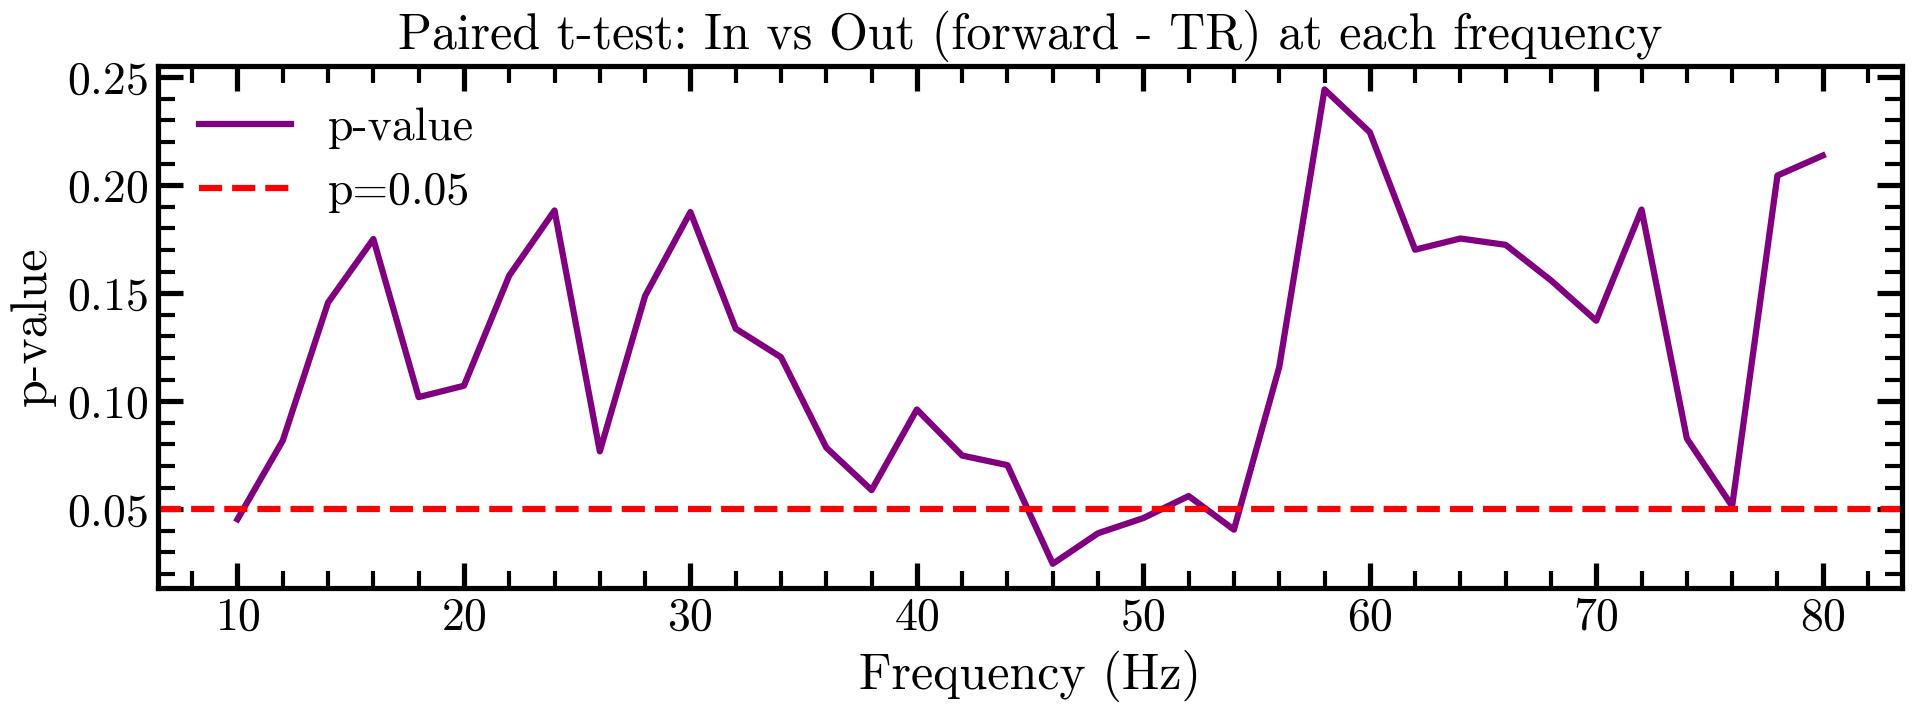

Significant frequencies (p < 0.05): [10. 46. 48. 50. 54.]


In [ ]:
from scipy.stats import ttest_rel

# Paired t-test at each frequency
# gc_in_tr_diff and gc_out_tr_diff: shape (n_subjects, n_freqs) or (n_samples, n_freqs)
# If they are means, use the original arrays (not means) for t-test

t_stats = []
p_values = []
for i in range(gc_in_tr_diff.shape[1]):
    t_stat, p_val = ttest_rel(gc_in_tr_diff[:, i], gc_out_tr_diff[:, i])
    t_stats.append(t_stat)
    p_values.append(p_val)
t_stats = np.array(t_stats)
p_values = np.array(p_values)

# Plot p-values across frequency
plt.figure(figsize=(10, 4), dpi=200)
plt.plot(freqs, p_values, label='p-value', color='purple')
plt.axhline(0.05, color='red', linestyle='--', label='p=0.05')
plt.xlabel('Frequency (Hz)')
plt.ylabel('p-value')
plt.title('Paired t-test: In vs Out (forward - TR) at each frequency')
plt.legend()
plt.tight_layout()
plt.show()

# Print significant frequencies
significant_freqs = freqs[p_values < 0.05]
print('Significant frequencies (p < 0.05):', significant_freqs)